# Algoritmo de Deutsch-Jozsa

O primeiro a demonstrar uma vantagewm quäntica provãvel sobre qualquer algoritmo clássico

O problema: Você tem uma função misteriosoa `f(x)` que recebe n bits e retorna 0 ou 1. A função é garantidamente ou constante (retorna sempre o mesmo valor) ou balanceada (retorna 0 para exatamente metade dos inputs e 1 para a outra medate). Classicamente você precisa de até 2ⁿ⁻¹+1  chamadas para ter certeza. Quanticamente: 1 chamada, sempre

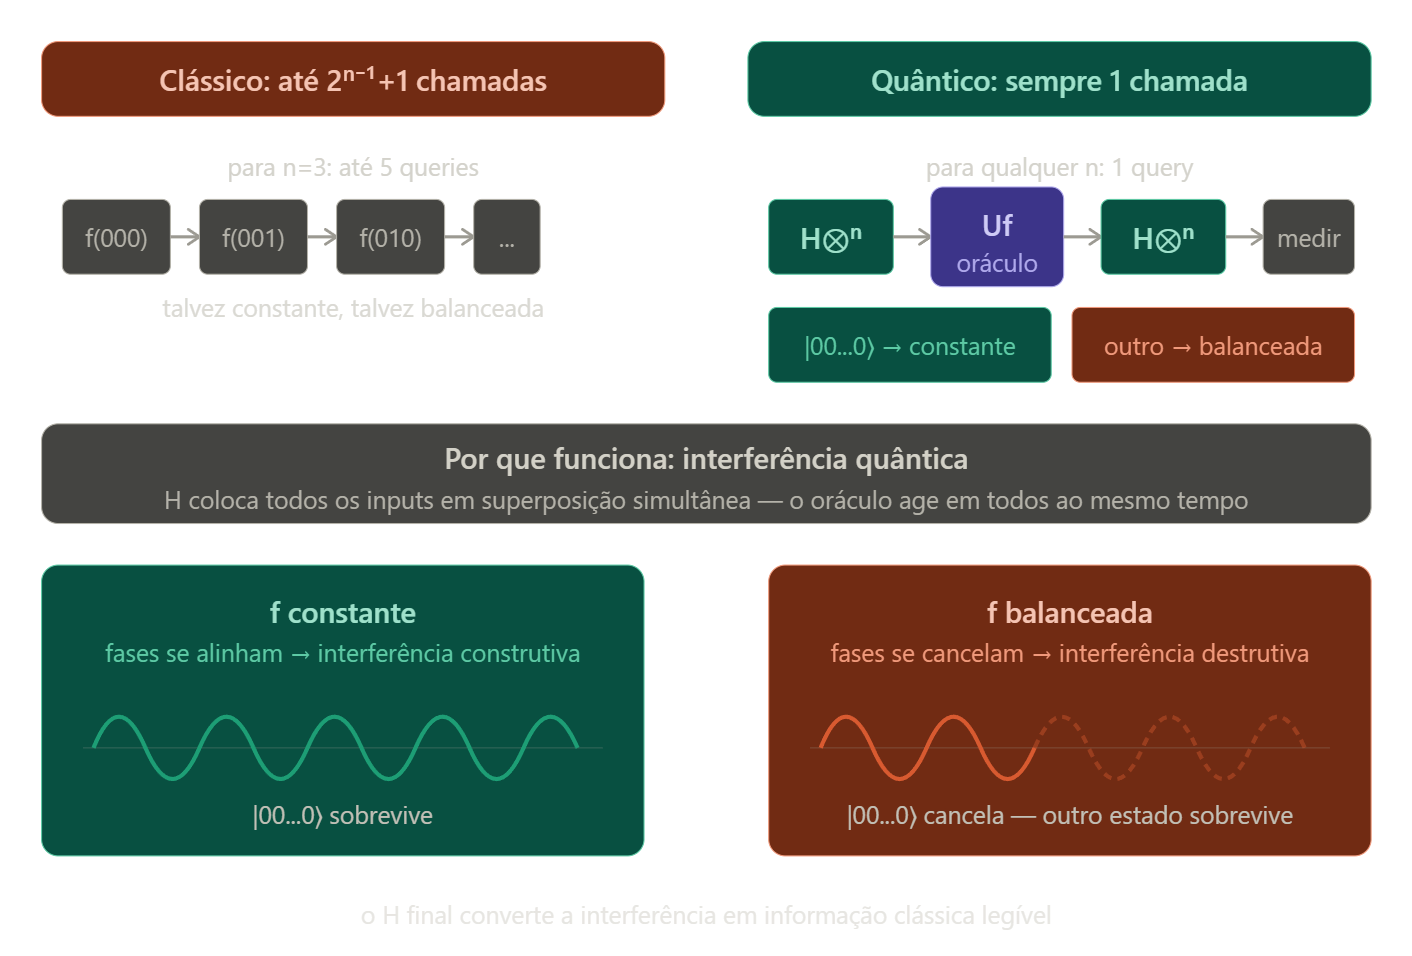
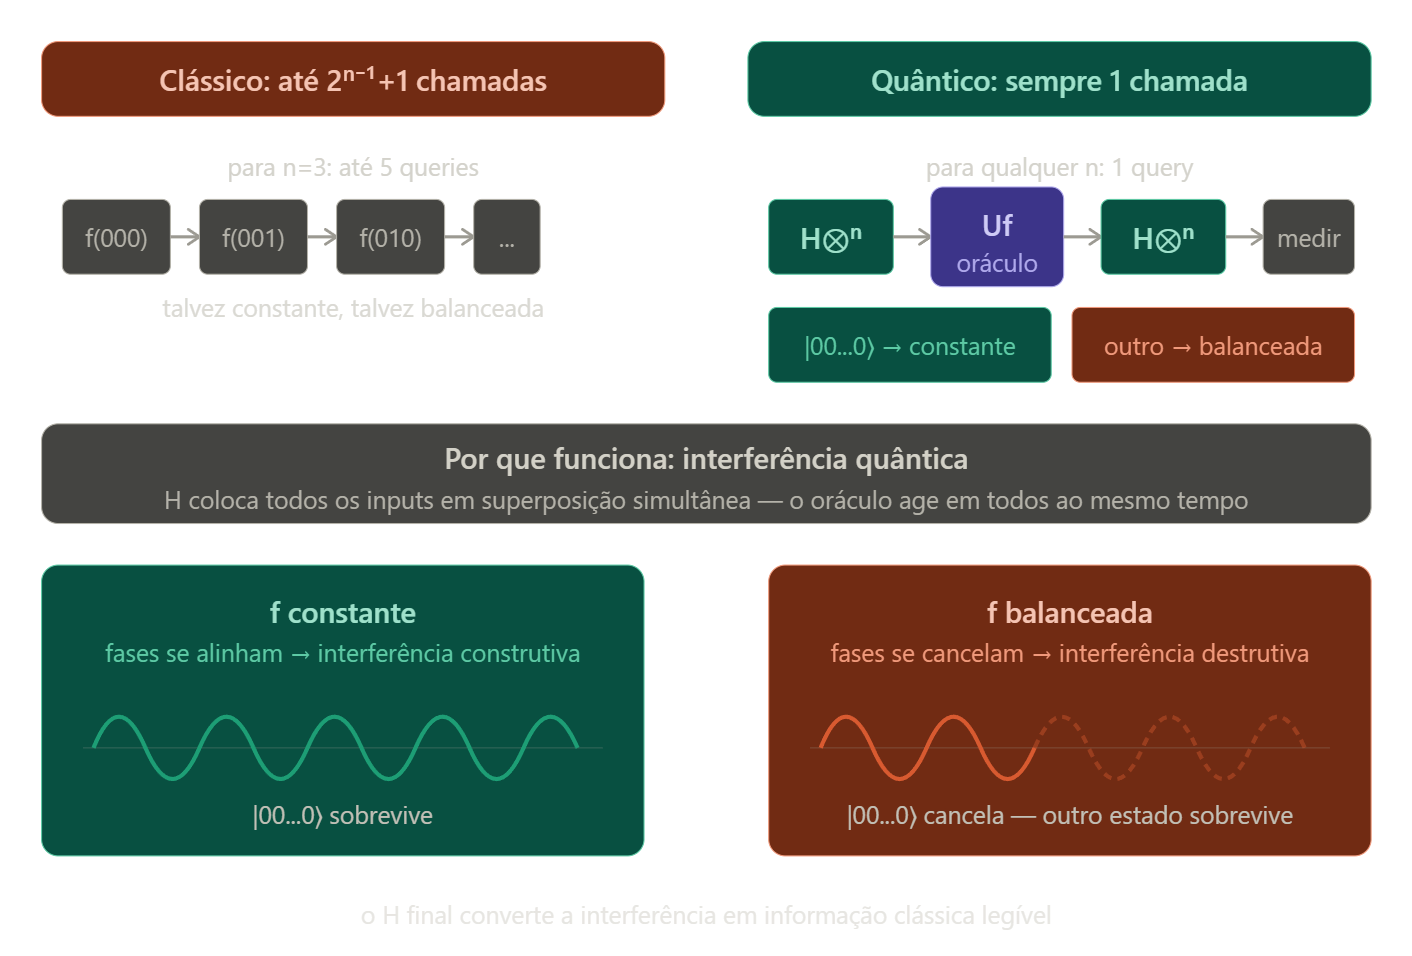
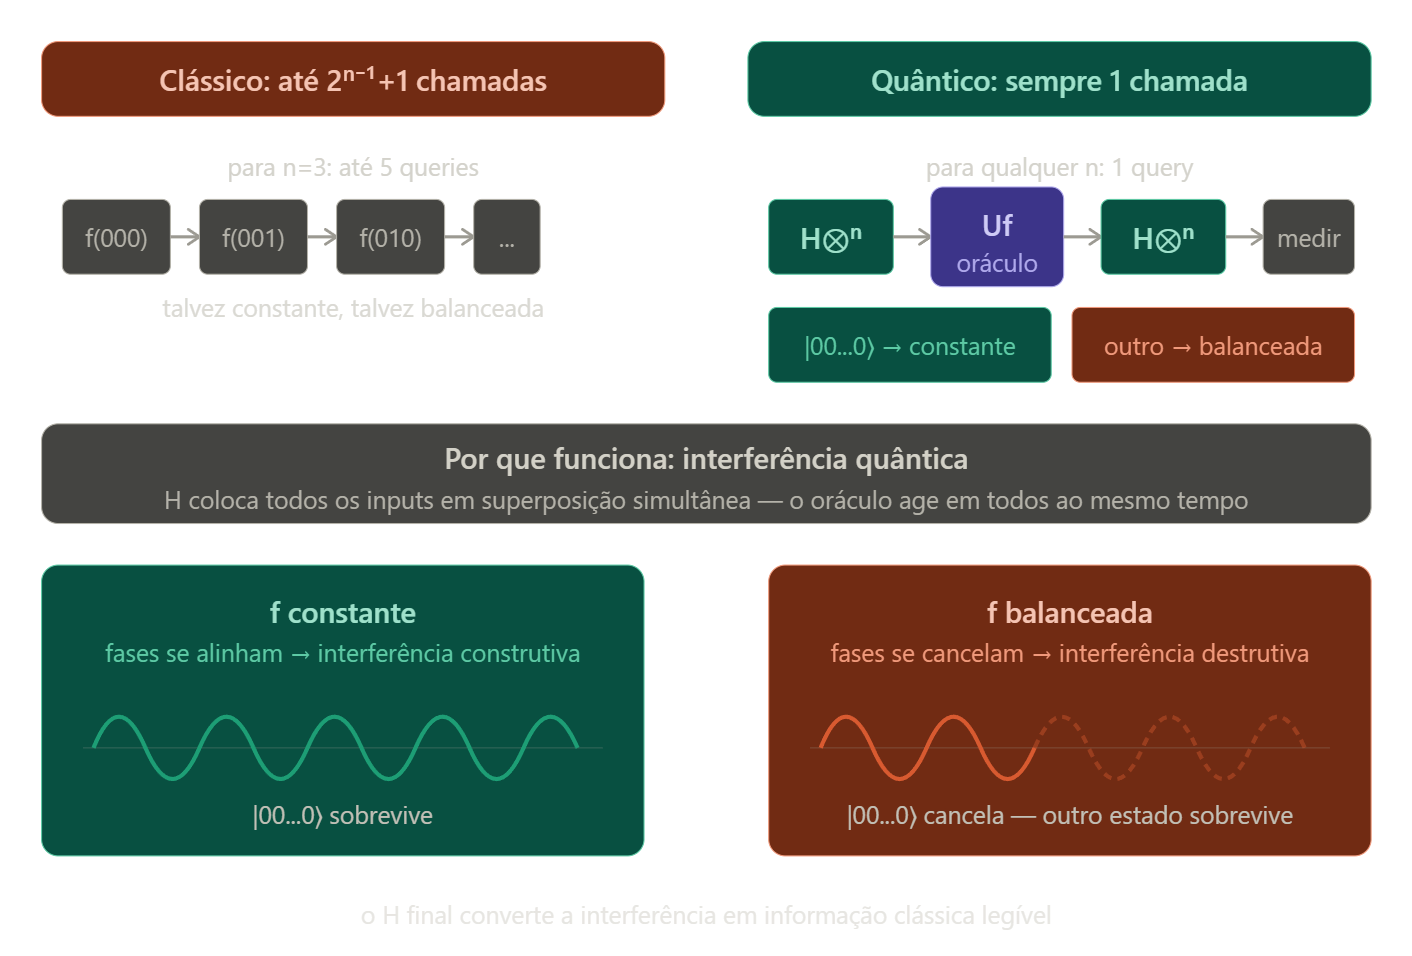
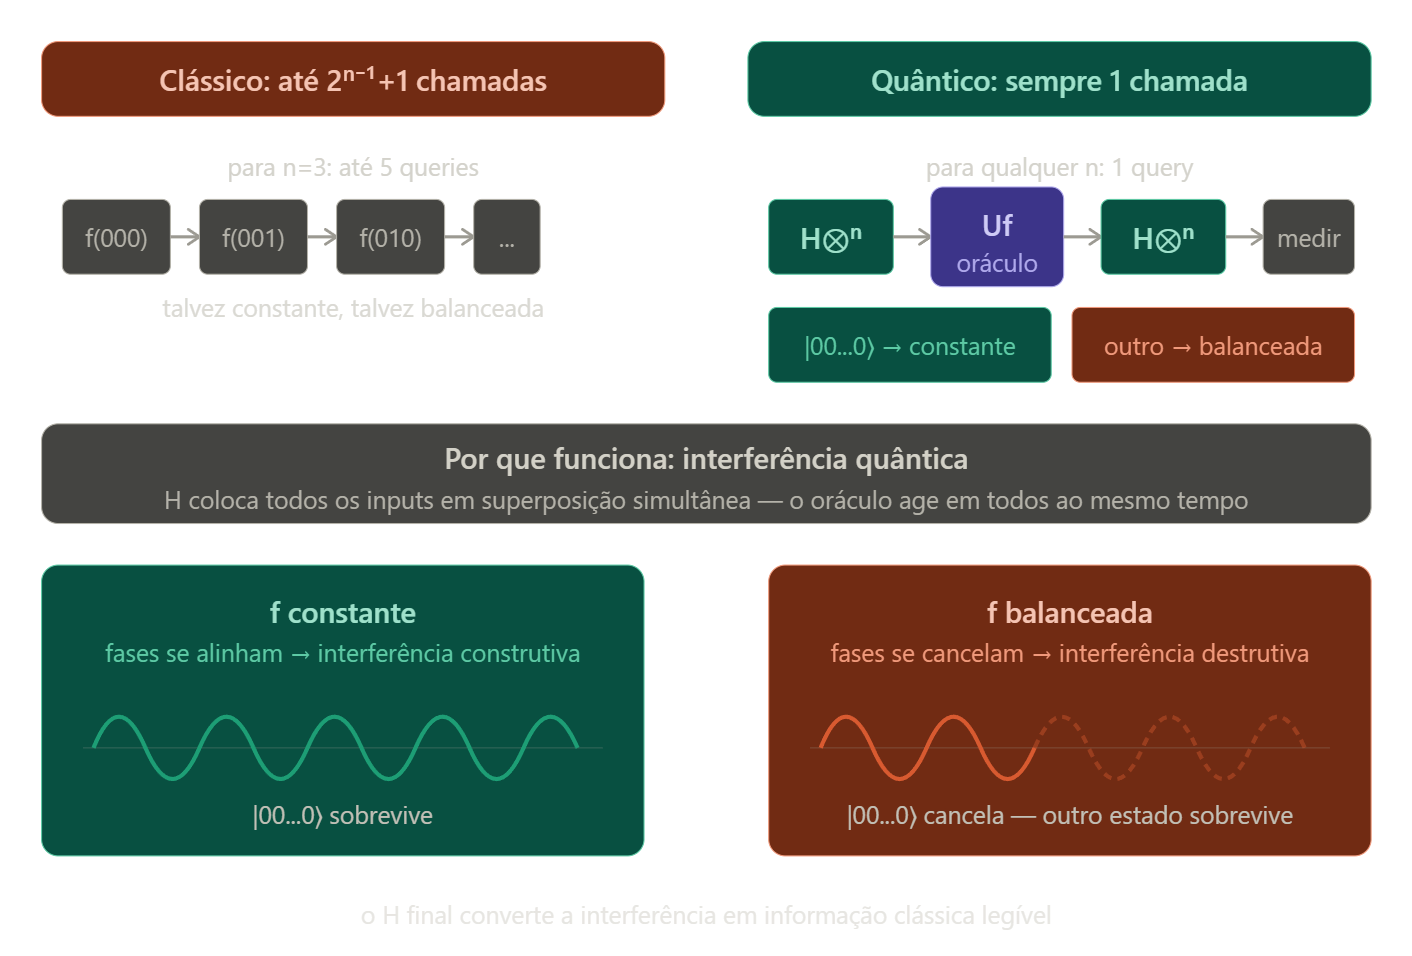
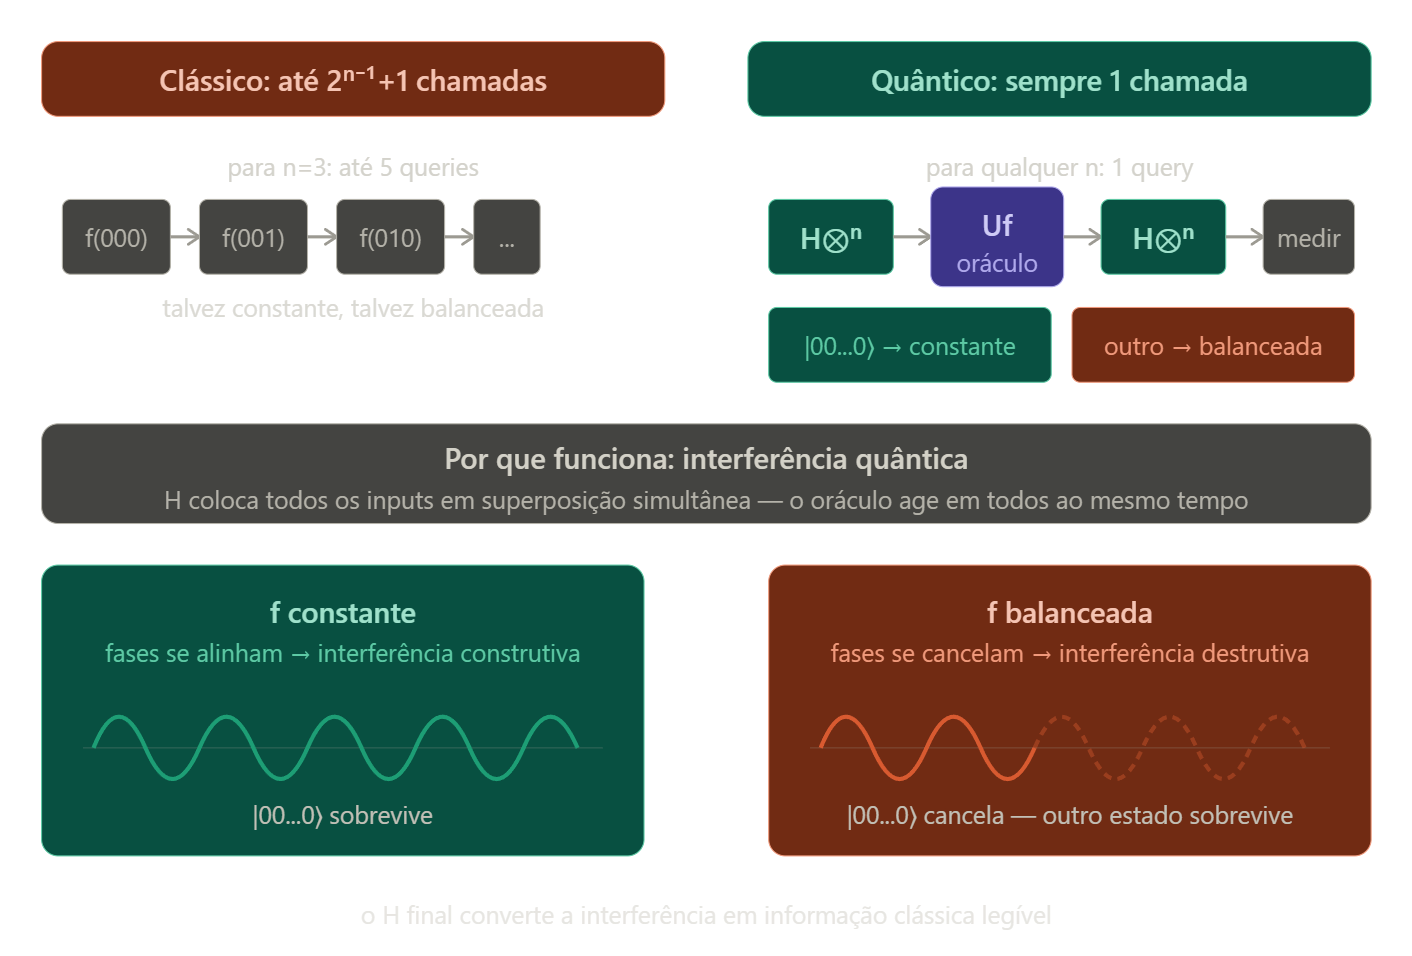
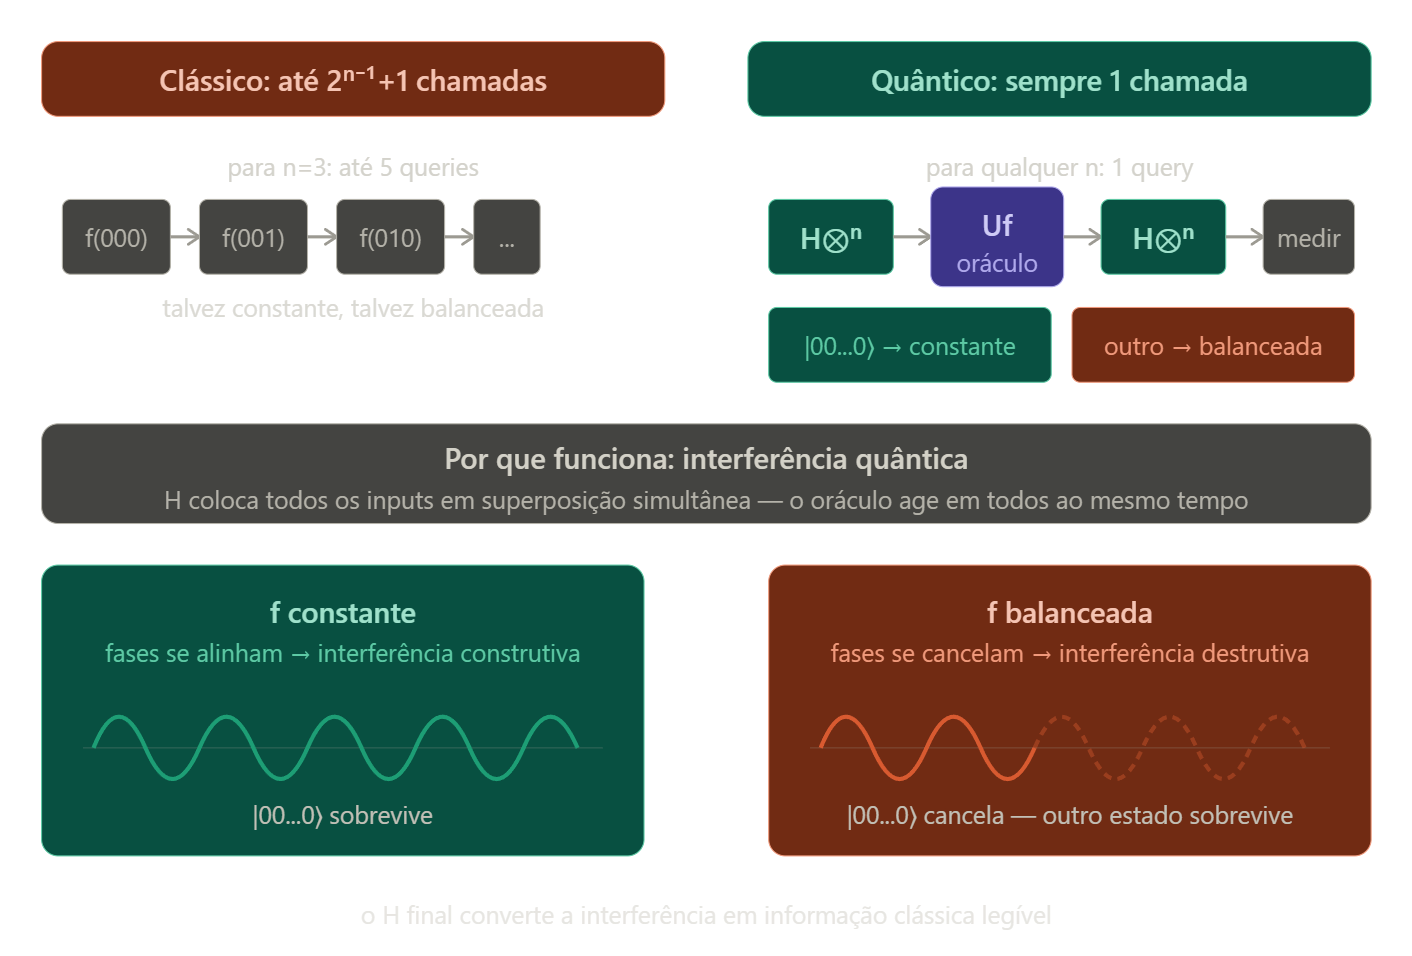
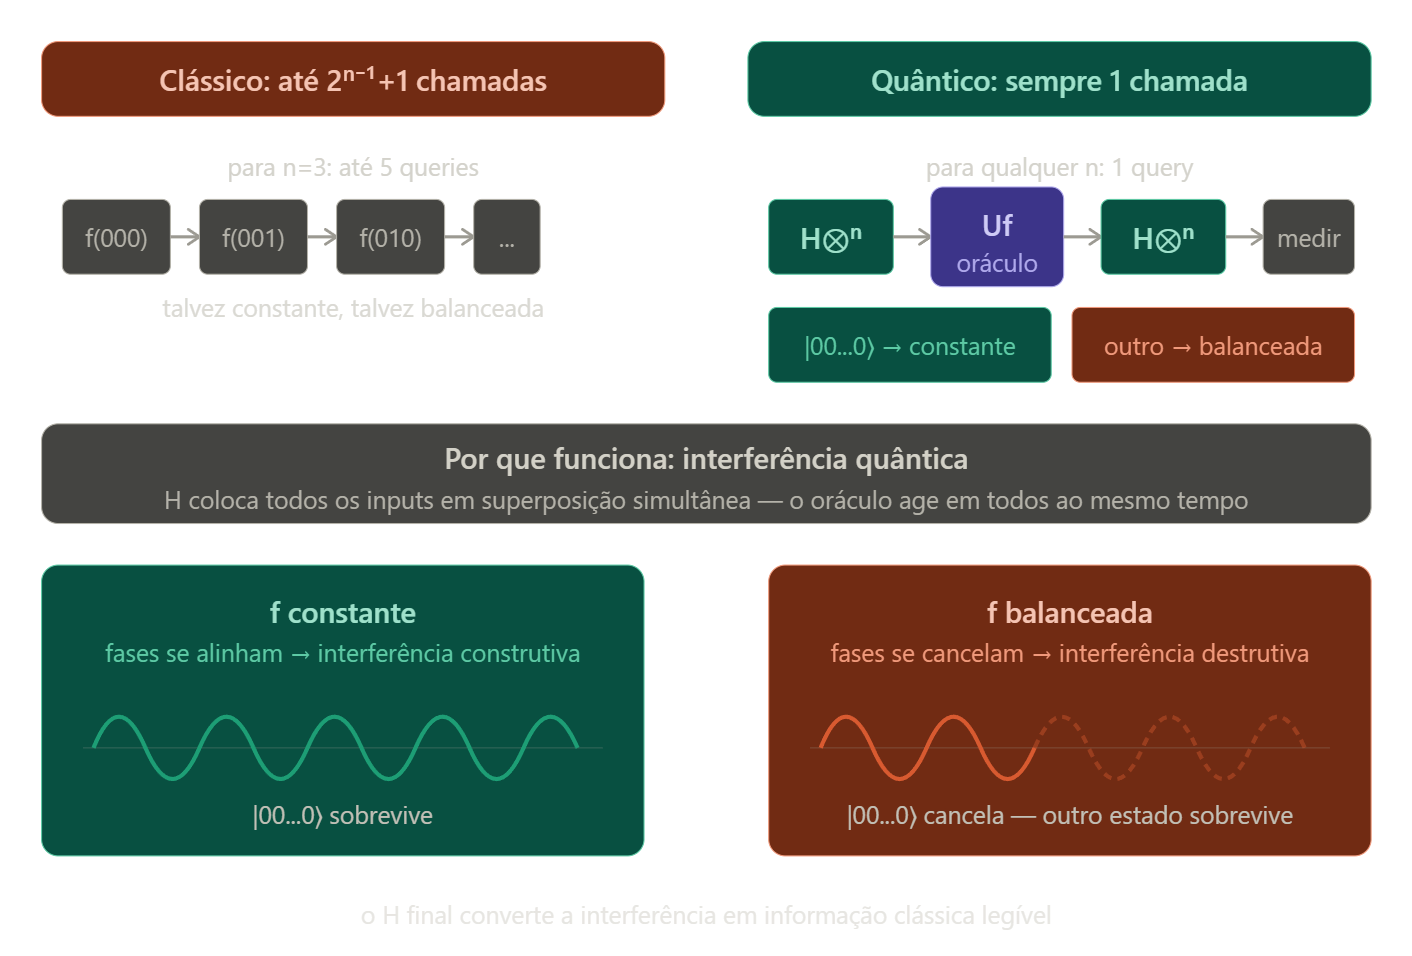

## Intuição geral

O H inicial coloca todos os 2ⁿ inputs em superposição ao mesmo tempo. O oráculo age em todos simultaneamente. O H final transforma interferência construtiva/destrutiva em bits legíveis. Se a função é constante, todas as fases apontam para o mesmo lugar — |00...0⟩ sobrevive. Se é balanceada, metade cancela a outra — |00...0⟩ some.

## Codigo QisKit - Versão com oráculos reais

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ── Oráculos ───────────────────────────────────────────────────────────

def oracle_constant_0(n: int) -> QuantumCircuit:
    """f(x) = 0 para todo x — não faz nada"""
    return QuantumCircuit(n + 1)

def oracle_constant_1(n: int) -> QuantumCircuit:
    """f(x) = 1 para todo x — flip no qubit ancilla"""
    qc = QuantumCircuit(n + 1)
    qc.x(n)   # ancilla é o qubit n
    return qc

def oracle_balanced_parity(n: int) -> QuantumCircuit:
    """
    f(x) = XOR de todos os bits de x
    balanceada: 0 para metade dos inputs, 1 para outra metade
    """
    qc = QuantumCircuit(n + 1)
    for i in range(n):
        qc.cx(i, n)   # CNOT de cada input para ancilla
    return qc

def oracle_balanced_first_bit(n: int) -> QuantumCircuit:
    """f(x) = primeiro bit de x"""
    qc = QuantumCircuit(n + 1)
    qc.cx(0, n)
    return qc

# ── Algoritmo de Deutsch-Jozsa ─────────────────────────────────────────

def deutsch_jozsa(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """
    n: número de qubits de input
    oracle: circuito de n+1 qubits (n input + 1 ancilla)
    """
    qc = QuantumCircuit(n + 1, n)

    # Passo 1: ancilla começa em |1⟩
    qc.x(n)

    # Passo 2: H em todos os qubits
    # input qubits → superposição de todos os 2ⁿ estados
    # ancilla → |−⟩ = (|0⟩ − |1⟩)/√2  (phase kickback vai funcionar aqui)
    qc.h(range(n + 1))
    qc.barrier(label="superposição")

    # Passo 3: aplicar o oráculo
    qc.compose(oracle, inplace=True)
    qc.barrier(label="oráculo")

    # Passo 4: H nos qubits de input novamente
    qc.h(range(n))
    qc.barrier(label="interferência")

    # Passo 5: medir os n qubits de input
    # |00...0⟩ → constante
    # qualquer outra coisa → balanceada
    qc.measure(range(n), range(n))

    return qc

def classificar(counts: dict, n: int) -> str:
    resultado = max(counts, key=counts.get)
    if resultado == '0' * n:
        return "CONSTANTE"
    else:
        return "BALANCEADA"

# ── Testar com n=3 ─────────────────────────────────────────────────────
sim = AerSimulator()
n = 3

testes = {
    "constante 0":      oracle_constant_0(n),
    "constante 1":      oracle_constant_1(n),
    "balanceada parity":oracle_balanced_parity(n),
    "balanceada 1bit":  oracle_balanced_first_bit(n),
}

print(f"Deutsch-Jozsa com n={n} qubits")
print("─" * 44)

for nome, oracle in testes.items():
    qc = deutsch_jozsa(oracle, n)
    job = sim.run(qc, shots=1024)
    counts = job.result().get_counts()
    resultado = classificar(counts, n)
    print(f"  {nome:<22} → {resultado}  {counts}")

Deutsch-Jozsa com n=3 qubits
────────────────────────────────────────────
  constante 0            → CONSTANTE  {'000': 1024}
  constante 1            → CONSTANTE  {'000': 1024}
  balanceada parity      → BALANCEADA  {'111': 1024}
  balanceada 1bit        → BALANCEADA  {'001': 1024}


In [4]:
# ── Visualizar o circuito ──────────────────────────────────────────────
qc = deutsch_jozsa(oracle_balanced_parity(3), 3)
print(qc.draw('text'))

     ┌───┐      superposição                 oráculo ┌───┐ interferência ┌─┐   »
q_0: ┤ H ├───────────░─────────■────────────────░────┤ H ├───────░───────┤M├───»
     ├───┤           ░         │                ░    ├───┤       ░       └╥┘┌─┐»
q_1: ┤ H ├───────────░─────────┼────■───────────░────┤ H ├───────░────────╫─┤M├»
     ├───┤           ░         │    │           ░    ├───┤       ░        ║ └╥┘»
q_2: ┤ H ├───────────░─────────┼────┼────■──────░────┤ H ├───────░────────╫──╫─»
     ├───┤┌───┐      ░       ┌─┴─┐┌─┴─┐┌─┴─┐    ░    └───┘       ░        ║  ║ »
q_3: ┤ X ├┤ H ├──────░───────┤ X ├┤ X ├┤ X ├────░────────────────░────────╫──╫─»
     └───┘└───┘      ░       └───┘└───┘└───┘    ░                ░        ║  ║ »
c: 3/═════════════════════════════════════════════════════════════════════╩══╩═»
                                                                          0  1 »
«        
«q_0: ───
«        
«q_1: ───
«     ┌─┐
«q_2: ┤M├
«     └╥┘
«q_3: ─╫─
«      ║ 
«c: 3/═╩═
«      2 

## Codigo Cirq

In [5]:
import cirq

def deutsch_jozsa_cirq(n: int, balanced: bool = True):
    qubits = cirq.LineQubit.range(n + 1)
    input_q = qubits[:n]
    ancilla = qubits[n]

    circuit = cirq.Circuit()

    # Ancilla → |1⟩
    circuit.append(cirq.X(ancilla))

    # H em todos
    circuit.append([cirq.H(q) for q in qubits])

    # Oráculo
    if balanced:
        # parity oracle: CNOT de cada input para ancilla
        circuit.append([cirq.CNOT(q, ancilla) for q in input_q])
    else:
        # constante 0: não faz nada
        pass

    # H nos inputs
    circuit.append([cirq.H(q) for q in input_q])

    # Medir
    circuit.append([cirq.measure(q, key=f'q{i}') for i, q in enumerate(input_q)])

    return circuit


sim = cirq.Simulator()

for balanced, tipo in [(False, "constante"), (True, "balanceada")]:
    circuit = deutsch_jozsa_cirq(n=3, balanced=balanced)
    result = sim.run(circuit, repetitions=1)

    bits = ''.join(str(result.measurements[f'q{i}'][0][0]) for i in range(3))
    classe = "CONSTANTE" if bits == "000" else "BALANCEADA"
    print(f"  {tipo:<12} → mediu {bits} → {classe}")

    print(circuit)

  constante    → mediu 000 → CONSTANTE
0: ───H───H───M('q0')───

1: ───H───H───M('q1')───

2: ───H───H───M('q2')───

3: ───X───H─────────────
  balanceada   → mediu 111 → BALANCEADA
0: ───H───────@───H───M('q0')───────────────────────
              │
1: ───H───────┼───@───H─────────M('q1')─────────────
              │   │
2: ───H───────┼───┼───@─────────H─────────M('q2')───
              │   │   │
3: ───X───H───X───X───X─────────────────────────────


## Phase kickback - mecanismo que faz tudo funcionar

Ancilla começa em |−⟩ = (|0⟩ − |1⟩)/√2

Quando o oráculo aplica f(x):
    Uf|x⟩|−⟩ = |x⟩ ⊗ (|f(x)⟩ ⊕ |−⟩)
             = (−1)^f(x) |x⟩|−⟩

O fator (−1)^f(x) "chuta de volta" para o input!

Se f é CONSTANTE (f(x) = c para todo x):
    todos os |x⟩ ganham a mesma fase (−1)^c
    fase global não tem efeito observável
    H final → todos interferem construtivamente em |00...0⟩

Se f é BALANCEADA:
    metade dos |x⟩ ganha fase +1, metade ganha −1
    H final → |00...0⟩ cancela completamente
    a amplitude vai para outros estados

In [6]:
from qiskit.quantum_info import Statevector

def mostrar_statevector(oracle, n, label):
    qc = QuantumCircuit(n + 1)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(oracle, inplace=True)
    # NÃO aplica H final — vemos o estado após o oráculo
    sv = Statevector(qc)
    print(f"\nApós oráculo ({label}):")
    for i, amp in enumerate(sv):
        if abs(amp) > 0.01:
            estado = format(i, f'0{n+1}b')
            print(f"  |{estado}⟩: {amp:.3f}")

mostrar_statevector(oracle_constant_0(2), 2, "constante 0")
mostrar_statevector(oracle_balanced_parity(2), 2, "balanceada parity")

# Constante 0: todas as amplitudes com a mesma fase → H as colapsa em |000⟩
# Balanceada:  amplitudes com fases opostas → H produz cancelamento em |000⟩


Após oráculo (constante 0):
  |000⟩: 0.354+0.000j
  |001⟩: 0.354+0.000j
  |010⟩: 0.354+0.000j
  |011⟩: 0.354+0.000j
  |100⟩: -0.354+0.000j
  |101⟩: -0.354+0.000j
  |110⟩: -0.354+0.000j
  |111⟩: -0.354+0.000j

Após oráculo (balanceada parity):
  |000⟩: 0.354+0.000j
  |001⟩: -0.354+0.000j
  |010⟩: -0.354+0.000j
  |011⟩: 0.354+0.000j
  |100⟩: -0.354+0.000j
  |101⟩: 0.354+0.000j
  |110⟩: 0.354+0.000j
  |111⟩: -0.354+0.000j


Após oráculo (constante 0) - fases alternadas por causa do |−⟩ — mas simétricas entre os inputs

Após oráculo (balanceada parity) - metade dos inputs tem fase invertida — assimetria que H vai amplificar